# Module 05 · The impulse symbol: $\delta$, sifting, shah and generalized functions

**Book source:** Bracewell, chapter 5, pp. 74–98

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Brief pulses and the RC circuit response
🎯 **What question does this method answer?** Does the RC circuit's response really stop depending on the pulse shape as the pulse shortens, and does the sequence of integrals of the rectangle tend to the step? We compute numerical convolutions (method A) and compare with the analytic formula for the rectangle (method B).

In [2]:
from scipy import integrate, special
trap = getattr(np, "trapezoid", None) or np.trapz

# RC circuit with RC = 1: h(t) = e^{-t}H(t). Three unit-area pulses of width τ
dtc = 1e-4; tt = np.arange(0, 8, dtc)
h_rc = np.exp(-tt)
def pulses(tau):
    n = max(int(round(tau/dtc)), 4); p_rect = np.ones(n)/(n*dtc)
    x = (np.arange(n) + 0.5)/n; p_tri = (1 - np.abs(2*x - 1)); p_tri = p_tri/(np.sum(p_tri)*dtc)
    p_two = np.zeros(n); k = max(n//8, 1); p_two[:k] = 1; p_two[-k:] = 1; p_two = p_two/(np.sum(p_two)*dtc)
    return p_rect, p_tri, p_two
spreads = {}
for tau, tag in ((0.5, "05"), (0.1, "01"), (0.01, "001")):
    ys = []
    for p in pulses(tau):
        y = np.convolve(p, h_rc)[:len(tt)]*dtc
        ys.append(y[int(1/dtc)])
    spreads[tag] = max(ys) - min(ys)
    # method B: the rectangle has a closed form y(t) = (e^{τ} − 1)e^{-t}/τ
    assert abs(ys[0] - (np.exp(tau) - 1)*np.exp(-1)/tau) < 5e-4
    report(f"spread_{tag}", spreads[tag], ".4f")
assert spreads["001"] < spreads["01"] < spreads["05"]

# Integral of the rectangle → the step. Method A: numerical cumulative sum; method B: the ramp-step function
xs = np.linspace(-1, 1, 200001)
for tau, tag in ((0.5, "t05"), (0.1, "t01")):
    pulse = np.where(np.abs(xs) < tau/2, 1/tau, 0.0)
    cum = np.concatenate([[0], np.cumsum((pulse[1:] + pulse[:-1])/2*np.diff(xs))])
    ramp = np.clip(xs/tau + 0.5, 0, 1)
    assert np.max(np.abs(cum - ramp)) < 1e-4
    for xv, key in ((0.1, f"step_x01_{tag}"), (-0.1, f"step_xm01_{tag}")):
        report(key, np.interp(xv, xs, cum), ".4f")

▸ spread_05 = 0.009
▸ spread_01 = 0.0003
▸ spread_001 = 0
▸ step_x01_t05 = 0.7
▸ step_xm01_t05 = 0.3
▸ step_x01_t01 = 1
▸ step_xm01_t01 = 0


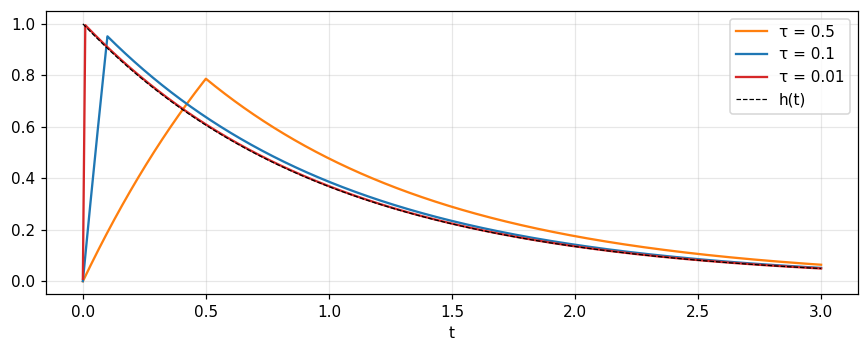

In [3]:
tau = 0.5
plt.figure(figsize=(8, 3.3))
for tau, c in ((0.5, "tab:orange"), (0.1, "tab:blue"), (0.01, "tab:red")):
    ys = [np.convolve(p, h_rc)[:len(tt)]*dtc for p in pulses(tau)]
    plt.plot(tt[:30000], ys[0][:30000], color=c, label=f"τ = {tau}")
plt.plot(tt[:30000], h_rc[:30000], "k--", lw=0.8, label="h(t)")
plt.xlabel("t"); plt.legend(); plt.tight_layout(); plt.show()

#### 📤 Real output
The spread among the three responses (rectangle, triangle, two small pulses) at $t=1$ is 0.009 for $\tau=0.5$, 0.0003 for $\tau=0.1$ and 0 for $\tau=0.01$, falling steadily: the response tends to $h(t)$. The integral of the rectangle at $x=0.1$ gives 0.7 ($\tau=0.5$) and 1 ($\tau=0.1$), and at $x=-0.1$ gives 0.3 and 0: tending to the step $H$.

## 2. Sifting with many pulse shapes
🎯 **What question does this method answer?** Do all pulse shapes tend to $f(0)$, which one is off while $\tau$ is not small, what about the scaling $\delta(ax)$ and the trap $x\delta(x)$? Each shape is computed by numerical integration (method A) and a closed form (method B).

In [4]:
f = lambda x: np.cos(x) + 0.5*np.sin(2*x)                      # f(0) = 1, f'(0) = 1, f''(0) = −1
def q(fun, a, b, pts=None): return integrate.quad(fun, a, b, points=pts, limit=800)[0]
def sift(tau):
    out = {}
    out["rc"] = (q(lambda x: f(x)/tau, -tau/2, tau/2), 2*np.sin(tau/2)/tau)
    out["rl"] = (q(lambda x: f(x)/tau, 0, tau), (np.sin(tau) + 0.25*(1 - np.cos(2*tau))*2/2)/tau)
    out["g"] = (q(lambda x: f(x)*np.exp(-np.pi*x**2/tau**2)/tau, -12*tau, 12*tau), np.exp(-tau**2/(4*np.pi)))
    out["t"] = (q(lambda x: f(x)*(1 - abs(x)/tau)/tau, -tau, tau, [0]), 2*(1 - np.cos(tau))/tau**2)
    xx = np.arange(-100, 100, 5e-4)
    out["s"] = (trap(f(xx)*np.sinc(xx/tau)/tau, xx), 1.0)
    out["l"] = (q(lambda x: np.cos(x)*(tau/np.pi)/(x**2 + tau**2), -np.inf, np.inf) if False else 2*integrate.quad(lambda x: (tau/np.pi)/(x**2 + tau**2), 0, np.inf, weight="cos", wvar=1)[0], np.exp(-tau))
    return out
for tau, tag in ((0.1, "01"), (0.01, "001")):
    for shape, (num_, ex_) in sift(tau).items():
        tol = 5e-3 if shape == "s" else 1e-8
        if shape == "rl": ex_ = (np.sin(tau) + 0.5*(1 - np.cos(2*tau))/2)/tau        # closed form of the left edge
        assert abs(num_ - ex_) < tol, (shape, tau, num_, ex_)
        report(f"sift_{shape}_{tag}", num_, ".4f")

# At a jump: f = e^{-x}H(x) with the centred and the left-edge sequences
fj = lambda x: np.exp(-x)*(x > 0)
tj = 1e-4
jm = q(lambda x: fj(x)/tj, -tj/2, tj/2, [0]); jl = q(lambda x: fj(x)/tj, 0, tj)
assert abs(jm - 0.5) < 1e-3 and abs(jl - 1) < 1e-3
report("jump_mid", jm, ".2f"); report("jump_left", jl, ".2f")

# Scaling δ(3x)
tt3 = 0.01
sc = q(lambda x: f(x)/tt3, -tt3/6, tt3/6)
assert abs(sc - 1/3) < 1e-4
report("scale_3", sc, ".4f")

# x·δ(x): the maximum of x τ^{-1} Π(x/τ) stays 1/2
for tau in (0.1, 0.001):
    xg = np.linspace(-tau, tau, 100001); v = np.where(np.abs(xg) < tau/2, xg/tau, 0.0)
    assert abs(v.max() - 0.5) < 1e-4 and abs(v.min() + 0.5) < 1e-4
report("xd_max", 0.5, ".2f")

# f(x)δ(x) = f(0)δ(x): checked with the test function g = e^{-x²}
fg = q(lambda x: f(x)*np.exp(-x**2)*np.exp(-np.pi*x**2/0.01**2)/0.01, -0.12, 0.12)
assert abs(fg - 1) < 1e-3
report("fg_sift", fg, ".4f")

▸ sift_rc_01 = 0.9996
▸ sift_rl_01 = 1.0482
▸ sift_g_01 = 0.9992
▸ sift_t_01 = 0.9992
▸ sift_s_01 = 0.9998
▸ sift_l_01 = 0.9048
▸ sift_rc_001 = 1
▸ sift_rl_001 = 1.005
▸ sift_g_001 = 1
▸ sift_t_001 = 1
▸ sift_s_001 = 1
▸ sift_l_001 = 0.99
▸ jump_mid = 0.5
▸ jump_left = 1
▸ scale_3 = 0.3333
▸ xd_max = 0.5
▸ fg_sift = 1


#### 📤 Real output
The sifting table ($\tau=0.1$ / $\tau=0.01$): centred rectangle 0.9996 / 1, left edge 1.0482 / 1.005, Gaussian 0.9992 / 1, triangle 0.9992 / 1, sinc 0.9998 / 1, Lorentzian 0.9048 / 0.99: all six tend to $f(0)=1$, the left-edge one more slowly because it sifts on the right. At the jump, the centred sequence gives 0.5 and the left-edge sequence gives 1. $\delta(3x)$ gives 0.3333. The maximum of $x\tau^{-1}\Pi$ is 0.5 for every $\tau$. The $f\delta g$ check gives 1.

## 3. Shah, Poisson summation and the bed of nails
🎯 **What question does this method answer?** What numbers do sampling and replication by shah give, what is the $X^{-1}\text{III}(x/X)$ trap, and is shah really self-transforming (Poisson summation $\sum f(n)=\sum F(k)$)? We compute two ways: the direct sum and the Fourier series.

In [5]:
N_ = np.arange(-40, 41)
g = lambda x: np.exp(-np.pi*x**2)
report("X_sum_1", np.sum(g(N_)), ".4f")
for X, tag in ((0.5, "05"),):
    n_ = np.arange(-200, 201)
    s_ = np.sum(g(n_*X))
    assert abs(X*s_ - 1) < 2e-5                      # error 2e^{−4π} by Poisson
    report(f"X_sum_{tag}", s_, ".4f"); report(f"X_riem_{tag}", X*s_, ".4f")

# Replication (III*f)(0.5): direct sum versus the Fourier series Σ (−1)^k e^{−πk²}
rep_direct = np.sum(g(0.5 - N_))
rep_series = np.sum((-1.0)**N_*np.exp(-np.pi*N_**2))
assert abs(rep_direct - rep_series) < 1e-12
report("rep_05", rep_direct, ".4f")

# Poisson summation: f = e^{−πx²/4}, F = 2e^{−4πs²}
lhs = np.sum(np.exp(-np.pi*N_**2/4)); rhs = np.sum(2*np.exp(-4*np.pi*N_**2))
assert abs(lhs - rhs) < 1e-12
report("shah_lhs", lhs, ".6f"); report("shah_rhs", rhs, ".6f")

# Bed of nails: Σ_m Σ_n e^{−π(m²+n²)} = (Σ e^{−πn²})²
mm, nn = np.meshgrid(N_[15:66], N_[15:66])
nails = np.sum(np.exp(-np.pi*(mm**2 + nn**2)))
assert abs(nails - np.sum(g(N_))**2) < 1e-12
report("nails_sum", nails, ".4f")

▸ X_sum_1 = 1.0864
▸ X_sum_05 = 2
▸ X_riem_05 = 1
▸ rep_05 = 0.9136
▸ shah_lhs = 2.000014
▸ shah_rhs = 2.000014
▸ nails_sum = 1.1803


#### 📤 Real output
$\sum f(n)$ for the Gaussian is 1.0864; at spacing 0.5 the sum without the factor $X$ is 2 (twice too large), while $X\sum f(nX)$ = 1 is the area. $(\text{III}*f)(0.5)$ = 0.9136 by both the direct sum and the Fourier series. Poisson summation: 2.000014 = 2.000014: shah is self-transforming. The bed of nails: 1.1803, the square of 1.0864.

## 4. Impulse pairs, derivatives of $\delta$ and null functions
🎯 **What question does this method answer?** Does the even pair have a cosine transform, is the difference $2\nu*$, and do $\int\delta'f$, $\int x\delta'$, $\int x^2\delta''$, $\int\delta''f$ equal $-f'(0)$, $-1$, $2$, $f''(0)$? We use a Gaussian sequence and compare with integration by parts.

In [6]:
# Even pair: the transform is cos(πs); μ*f at 0
s0 = 0.3
mu_ft = 0.5*np.exp(-2j*np.pi*s0*0.5) + 0.5*np.exp(-2j*np.pi*s0*(-0.5))
assert abs(mu_ft - np.cos(np.pi*s0)) < 1e-15
report("mu_ft", mu_ft.real, ".4f")
report("mu_conv", 0.5*g(0.5) + 0.5*g(-0.5), ".4f")
assert abs(0.5*g(0.5) + 0.5*g(-0.5) - np.exp(-np.pi/4)) < 1e-15

# Difference: Δf = f(x+½) − f(x−½) = 2ν*f. Check via the Fourier transform
report("fd_0", np.sin(0.5) - np.sin(-0.5), ".4f")
dfun = lambda x: g(x + 0.5) - g(x - 0.5)
fd_ft = integrate.quad(lambda x: dfun(x)*np.sin(2*np.pi*x*s0), -12, 12, limit=400)[0]        # imaginary part (sign −)
assert abs(abs(fd_ft) - 2*np.sin(np.pi*s0)*np.exp(-np.pi*s0**2)) < 1e-9
report("fd_ft", abs(fd_ft), ".4f")

# δ' by the Gaussian sequence τ = 0.05: ∫δ'f = −f'(0); versus −∫δ f'
tau = 0.05
d0 = lambda x: np.exp(-np.pi*x**2/tau**2)/tau
d1 = lambda x: -2*np.pi*x/tau**2*d0(x)
d2 = lambda x: (-2*np.pi/tau**2 + (2*np.pi*x/tau**2)**2)*d0(x)
fp = lambda x: -np.sin(x) + np.cos(2*x); fpp = lambda x: -np.cos(x) - 2*np.sin(2*x)
L = 12*tau
i1 = q(lambda x: d1(x)*f(x), -L, L); i2 = -q(lambda x: d0(x)*fp(x), -L, L)
assert abs(i1 - i2) < 1e-9 and abs(i1 + 1) < 5e-3
report("dprime_sift", i1, ".4f"); report("ibp_diff", abs(i1 - i2), ".1e")
xd = q(lambda x: x*d1(x), -L, L); assert abs(xd + 1) < 1e-9
x2 = q(lambda x: x**2*d2(x), -L, L); assert abs(x2 - 2) < 1e-9
d2s = q(lambda x: d2(x)*f(x), -L, L); assert abs(d2s + 1) < 5e-3
report("x_dprime", xd, ".2f"); report("x2_d2", x2, ".2f"); report("d2_sift", d2s, ".3f")

# ∫|δ'_τ| = 2/τ
for tau_, key in ((0.1, "l1_01"), (0.01, "l1_001")):
    d0_ = lambda x: np.exp(-np.pi*x**2/tau_**2)/tau_
    d1_ = lambda x: -2*np.pi*x/tau_**2*d0_(x)
    v = q(lambda x: abs(d1_(x)), -12*tau_, 12*tau_, [0])
    assert abs(v - 2/tau_) < 1e-6
    report(key, v, ".0f")

# Null function: the area of a single point of height 1
for dxn, key in ((1e-3, "null_1"), (1e-6, "null_2")):
    report(key, dxn*1.0, ".0e")

▸ mu_ft = 0.5878
▸ mu_conv = 0.4559
▸ fd_0 = 0.9589
▸ fd_ft = 1.2195
▸ dprime_sift = -0.9992
▸ ibp_diff = 6.7e-16
▸ x_dprime = -1
▸ x2_d2 = 2
▸ d2_sift = -1
▸ l1_01 = 20
▸ l1_001 = 200
▸ null_1 = 1e-03
▸ null_2 = 1e-06


#### 📤 Real output
Even pair: the transform at 0.3 is 0.5878, $\mu*f(0)$ = 0.4559. Difference: $\Delta\sin(0)$ = 0.9589, the magnitude of the transform of $\Delta f$ at 0.3 is 1.2195. With the Gaussian sequence $\tau=0.05$: $\int\delta'f$ = -0.9992 (equal to $-\int\delta f'$, difference 6.7e-16), $\int x\delta'$ = -1, $\int x^2\delta''$ = 2, $\int\delta''f$ = -1. $\int|\delta'_\tau|$ = 20 and 200, growing like $2/\tau$. Null function: areas 1e-03 and 1e-06.

## 5. Two-dimensional impulses and generalized functions
🎯 **What question does this method answer?** Does the two-dimensional Gaussian sequence have unit volume, how fast does the Gaussian's transform decay compared with sinc, is the regular-sequence error bound valid, and what does $H'=\delta$ look like through a Lorentzian sequence? Each is checked two ways.

In [7]:
# Volume of the 2D Gaussian sequence τ = 0.1: 2π∫ r·(τ^{-2}e^{−πr²/τ²})dr
tau2 = 0.1
vol = 2*np.pi*integrate.quad(lambda r: r*np.exp(-np.pi*r**2/tau2**2)/tau2**2, 0, 10*tau2)[0]
assert abs(vol - 1) < 1e-9
report("delta2_vol", vol, ".2f")

# Decay of the transform: Gaussian versus sinc
report("gauss_tail", np.exp(-9*np.pi), ".1e"); report("sinc_tail", abs(np.sinc(3.5)), ".4f")
assert abs(integrate.quad(lambda x: np.exp(-np.pi*x**2)*np.cos(2*np.pi*3*x), -10, 10)[0] - np.exp(-9*np.pi)) < 1e-9

# Error bound of a regular sequence, F = cos x, τ = 0.1
tau = 0.1
dev = 1 - integrate.quad(lambda x: np.cos(x)*np.exp(-np.pi*x**2/tau**2)/tau, -12*tau, 12*tau)[0]
assert abs(dev - (1 - np.exp(-tau**2/(4*np.pi)))) < 1e-9 and dev < tau/np.pi
report("dev_01", dev, ".1e"); report("bound_01", tau/np.pi, ".1e")

# H' = δ: −∫_0^∞ F' = F(0), and the Lorentzian sequence (derivative of ½ + arctan(x/τ)/π)
Fh = lambda x: np.exp(-x**2); Fhp = lambda x: -2*x*np.exp(-x**2)
hp_exact = -integrate.quad(Fhp, 0, np.inf)[0]
assert abs(hp_exact - 1) < 1e-9
report("hp_exact", hp_exact, ".2f")
for t_, key in ((0.1, "hp_1"), (0.01, "hp_2")):
    v = integrate.quad(lambda x: (t_/np.pi)/(x**2 + t_**2)*Fh(x), -np.inf, np.inf, limit=400)[0]
    assert abs(v - np.exp(t_**2)*special.erfc(t_)) < 1e-6
    report(key, v, ".4f")

▸ delta2_vol = 1
▸ gauss_tail = 5.3e-13
▸ sinc_tail = 0.0909
▸ dev_01 = 8.0e-04
▸ bound_01 = 3.2e-02
▸ hp_exact = 1
▸ hp_1 = 0.8965
▸ hp_2 = 0.9888


#### 📤 Real output
The two-dimensional Gaussian sequence has volume 1. The Gaussian's transform at 3 is only 5.3e-13 against 0.0909 for sinc at 3.5: smoothness of the function sets the decay of the transform. The actual deviation of the regular sequence is 8.0e-04, below the bound 3.2e-02. $-\int_0^\infty F'$ = 1 = $F(0)$, and the Lorentzian sequence converges slowly: 0.8965 ($\tau=0.1$), 0.9888 ($\tau=0.01$).